In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_curve, auc

sys.path.append("../src")

from preprocessing import build_preprocessor
from models import get_models

# Setup paths
BASE_DIR = os.path.abspath("..")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
FIG_DIR = os.path.join(REPORTS_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
df = pd.read_csv("../data/dataset.csv")

target_column = "target"  # change if needed

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = build_preprocessor(X_train)
models = get_models()

In [4]:
overfitting_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    overfitting_results[name] = {
        "Train_Accuracy": train_acc,
        "Test_Accuracy": test_acc,
        "Gap": train_acc - test_acc
    }

overfit_df = pd.DataFrame(overfitting_results).T
overfit_df

,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.926750,0.928000,-0.001250
SVM,0.951333,0.949000,0.002333
DecisionTree,1.000000,0.915000,0.085000
RandomForest,1.000000,0.954667,0.045333


In [5]:
overfit_df.to_csv(os.path.join(REPORTS_DIR, "overfitting_analysis.csv"))

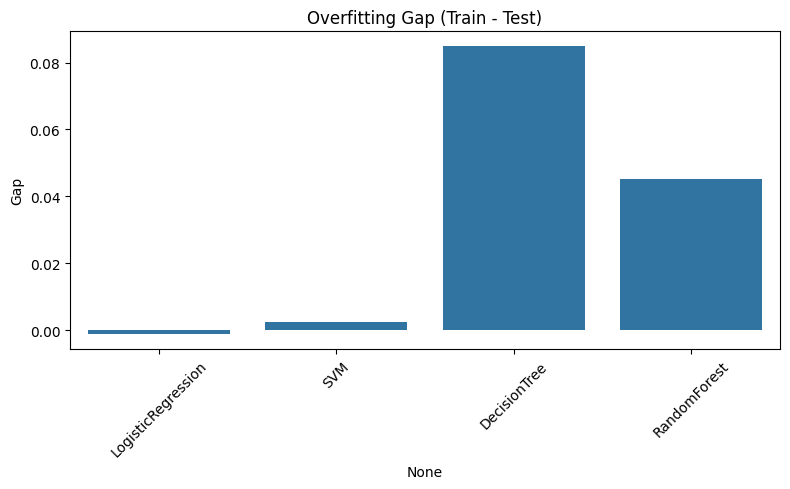

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x=overfit_df.index, y=overfit_df["Gap"])
plt.xticks(rotation=45)
plt.title("Overfitting Gap (Train - Test)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "overfitting_gap.png"))
plt.show()

In [12]:
results = pd.read_csv(os.path.join(REPORTS_DIR, "model_comparison.csv"), index_col=0)
results.head()

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486


In [8]:
import os
print(os.listdir(".."))

['.venv', 'data', 'notebooks', 'reports', 'requirements.txt', 'src']


In [9]:
print(os.listdir("../reports"))

['figures', 'overfitting_analysis.csv']


In [11]:
results = pd.read_csv("../reports/model_comparison.csv", index_col=0)

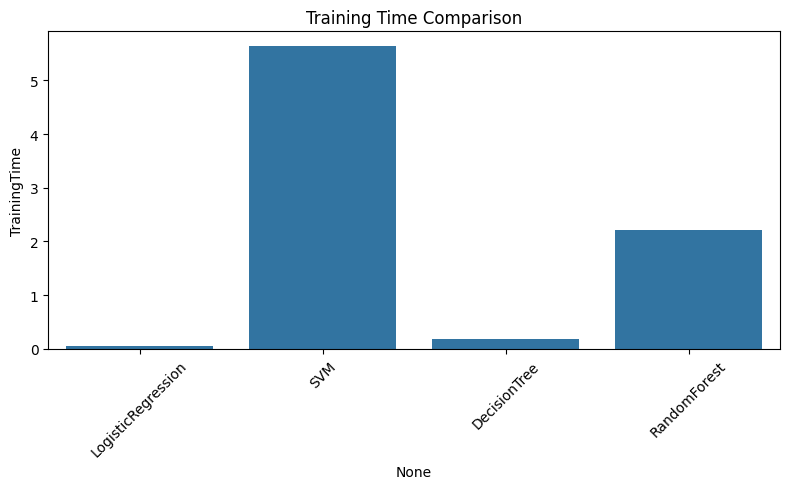

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x=results.index, y=results["TrainingTime"])
plt.xticks(rotation=45)
plt.title("Training Time Comparison")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_time.png"))
plt.show()

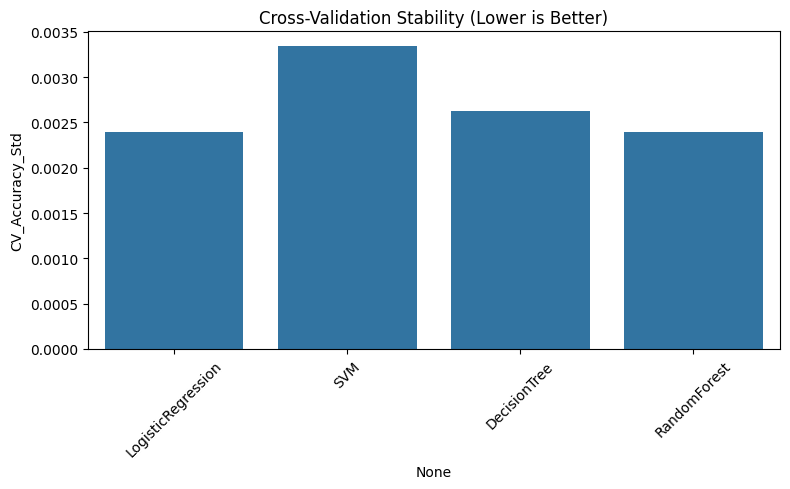

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x=results.index, y=results["CV_Accuracy_Std"])
plt.xticks(rotation=45)
plt.title("Cross-Validation Stability (Lower is Better)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cv_stability.png"))
plt.show()

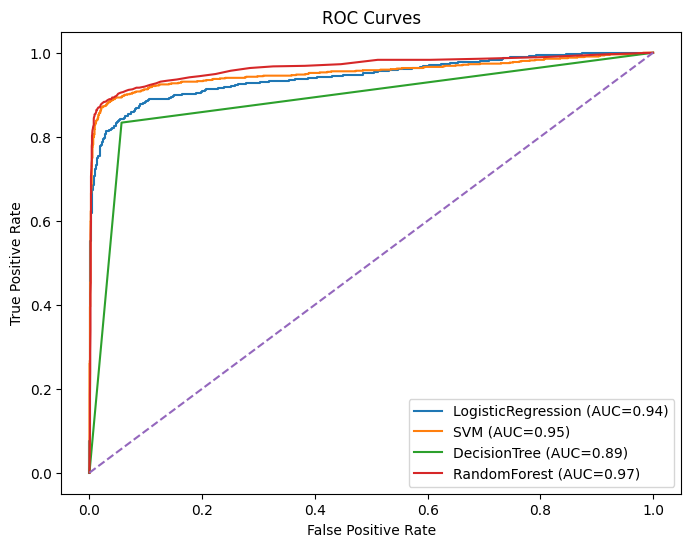

In [15]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:,1]
    else:
        y_prob = pipeline.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.savefig(os.path.join(FIG_DIR, "roc_curves.png"))
plt.show()

In [16]:
import pandas as pd
import os

BASE_DIR = os.path.abspath("..")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

results = pd.read_csv(os.path.join(REPORTS_DIR, "model_comparison.csv"), index_col=0)
overfit = pd.read_csv(os.path.join(REPORTS_DIR, "overfitting_analysis.csv"), index_col=0)

final_table = results.merge(overfit, left_index=True, right_index=True)

final_table

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333


In [18]:
final_table.to_csv(os.path.join(REPORTS_DIR, "final_comparison_table.csv"))

In [19]:
final_table.sort_values(by="CV_Accuracy_Mean", ascending=False)

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000


In [21]:
best_by_cv = final_table.sort_values(by="CV_Accuracy_Mean", ascending=False)
best_by_cv

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000


In [22]:
best_model_name = best_by_cv.index[0]
best_model_name

'RandomForest'

In [23]:
final_table.sort_values(by="CV_Accuracy_Std")

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333


In [24]:
final_table.sort_values(by="Gap")

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000


In [25]:
final_table.sort_values(by="TrainingTime")

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333


In [29]:
import pandas as pd
import os

BASE_DIR = os.path.abspath("..")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

results = pd.read_csv(os.path.join(REPORTS_DIR, "model_comparison.csv"), index_col=0)
overfit = pd.read_csv(os.path.join(REPORTS_DIR, "overfitting_analysis.csv"), index_col=0)

final_table = results.merge(overfit, left_index=True, right_index=True)

final_table.head()

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333


In [30]:
selection_table = final_table.copy()

selection_table["CV_Score"] = selection_table["CV_Accuracy_Mean"]
selection_table["Stability_Score"] = -selection_table["CV_Accuracy_Std"]
selection_table["Generalization_Score"] = -selection_table["Gap"]
selection_table["Speed_Score"] = -selection_table["TrainingTime"]

selection_table["Final_Score"] = (
    selection_table["CV_Score"] * 0.5 +
    selection_table["Stability_Score"] * 0.2 +
    selection_table["Generalization_Score"] * 0.2 +
    selection_table["Speed_Score"] * 0.1
)

selection_table

,Accuracy,Precision,Recall,F1,TrainingTime,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,Train_Accuracy,Test_Accuracy,Gap,CV_Score,Stability_Score,Generalization_Score,Speed_Score,Final_Score
LogisticRegression,0.928000,0.927900,0.928000,0.925896,0.051751,0.926417,0.002395,0.924133,0.002362,0.926750,0.928000,-0.001250,0.926417,-0.002395,0.001250,-0.051751,0.457804
SVM,0.949000,0.949905,0.949000,0.947635,5.632016,0.944417,0.003340,0.942938,0.003479,0.951333,0.949000,0.002333,0.944417,-0.003340,-0.002333,-5.632016,-0.092128
DecisionTree,0.915000,0.914964,0.915000,0.914982,0.187305,0.906167,0.002627,0.906124,0.002535,1.000000,0.915000,0.085000,0.906167,-0.002627,-0.085000,-0.187305,0.416827
RandomForest,0.954667,0.955311,0.954667,0.953635,2.219511,0.947583,0.002392,0.946536,0.002486,1.000000,0.954667,0.045333,0.947583,-0.002392,-0.045333,-2.219511,0.242296


In [31]:
final_selected_model = selection_table.sort_values(by="Final_Score", ascending=False).index[0]

final_selected_model

'LogisticRegression'